**practcing writing ML in python**


In [30]:
import pandas as pd
import matplotlib.pyplot as plt



df = pd.read_csv("../data/train.csv")
#print(df)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

**Cleaning up data**

In [31]:

df["PoolQC"] = df["PoolQC"].fillna("None")

cols = ["MiscFeature","Alley","Fence","FireplaceQu","GarageType","GarageCond","GarageQual","BsmtExposure","BsmtFinType2","BsmtQual","BsmtCond","BsmtFinType1"]
for col in cols:
    df[col] = df[col].fillna("None")
df["MasVnrType"]   = df["MasVnrType"].fillna("None")
df["GarageFinish"] = df["GarageFinish"].fillna("None")
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)
df["MasVnrArea"]  = df["MasVnrArea"].fillna(0)
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())
df["Electrical"]  = df["Electrical"].fillna(df["Electrical"].mode()[0])

missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)


Series([], dtype: int64)

**statistics**

In [32]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

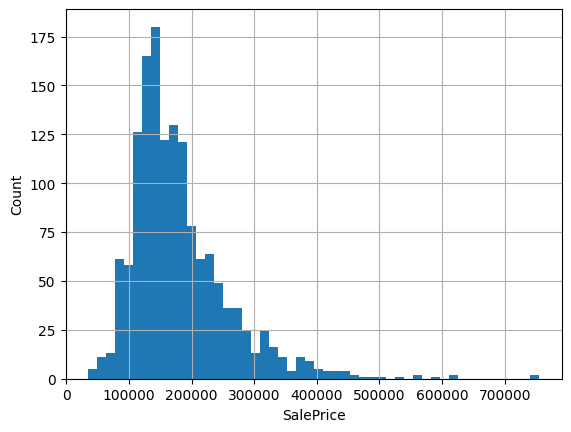

In [33]:
import matplotlib.pyplot as plt

df["SalePrice"].hist(bins = 50)
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

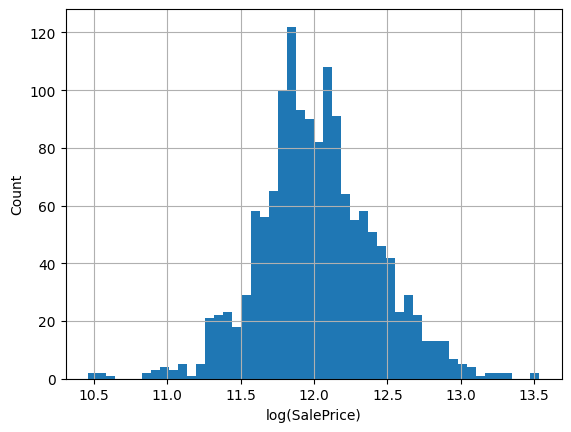

In [34]:
import numpy as np

np.log1p(df["SalePrice"]).hist(bins=50)
plt.xlabel("log(SalePrice)")
plt.ylabel("Count")
plt.show()

In [35]:
df_encoded = pd.get_dummies(df)
print(df_encoded.shape)

(1460, 304)


In [36]:
import numpy as np

X = df_encoded.drop("SalePrice", axis=1)
y = np.log1p(df_encoded["SalePrice"])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
print(X_train.shape, X_test.shape)

(1168, 303) (292, 303)


In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np


model = LinearRegression()        # create the model
model.fit(X_train, y_train)       # learn from training data ONLY
preds = model.predict(X_test)     # predict on held-out data
print(preds[:5])
print(y_test[:5].values)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE (log scale):", rmse)

preds_dollars = np.expm1(preds)
truth_dollars = np.expm1(y_test)
rmse_dollars = np.sqrt(mean_squared_error(truth_dollars, preds_dollars))
print("RMSE (dollars): $", rmse_dollars)

[11.94136897 12.74294085 11.51575059 12.01376031 12.64932998]
[11.94795585 12.69158354 11.6526961  11.97666577 12.66191713]
RMSE (log scale): 0.12859166580924797
RMSE (dollars): $ 22716.146391666203


In [45]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
print("Random Forest RMSE (log):", rf_rmse)

Random Forest RMSE (log): 0.14650142309147432


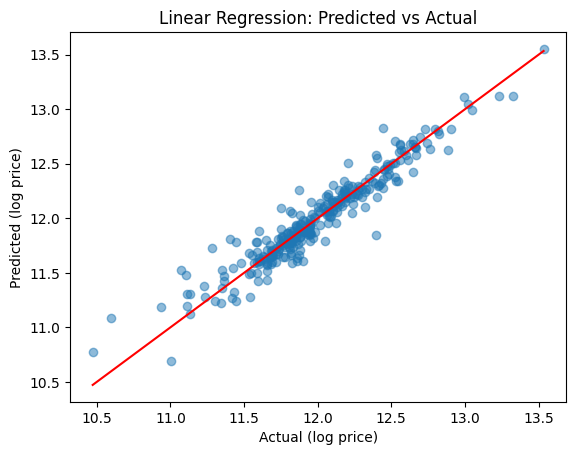

In [46]:
import matplotlib.pyplot as plt

plt.scatter(y_test, preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")  # the perfect-prediction line
plt.xlabel("Actual (log price)")
plt.ylabel("Predicted (log price)")
plt.title("Linear Regression: Predicted vs Actual")
plt.show()

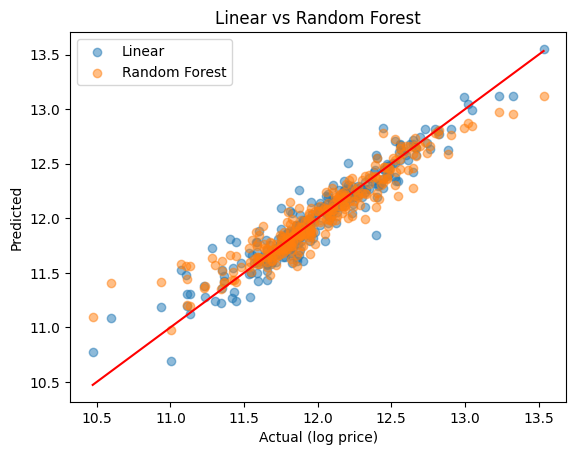

In [47]:
plt.scatter(y_test, preds, alpha=0.5, label="Linear")
plt.scatter(y_test, rf_preds, alpha=0.5, label="Random Forest")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.xlabel("Actual (log price)")
plt.ylabel("Predicted")
plt.legend()
plt.title("Linear vs Random Forest")
plt.show()

In [49]:
rf_tuned = RandomForestRegressor(
    n_estimators=300,    
    max_depth=15,        
    random_state=42
)
rf_tuned.fit(X_train, y_train)
rf_tuned_preds = rf_tuned.predict(X_test)

rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
print("Tuned RF RMSE (log):", rf_tuned_rmse)
print("Untuned RF was:      0.1465")
print("Linear baseline:     0.1286")

Tuned RF RMSE (log): 0.14701577802096477
Untuned RF was:      0.1465
Linear baseline:     0.1286


**optimizing Using GridSearch to try and beat Ridge model**

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [10, 20, None]   
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,                              
    scoring="neg_root_mean_squared_error"
    )
grid.fit(X_train, y_train)

print("Best settings:", grid.best_params_)
print("Best CV score:", -grid.best_score_)   

Best settings: {'max_depth': None, 'n_estimators': 100}
Best CV score: 0.1446816511875228
